In [1]:
import pandas as pd

df = pd.read_csv('data/Walmart_Store_sales.csv')
df = df.sample(1000)
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
6018,43,30-04-2010,630740.11,0,66.91,2.780,202.431224,9.593
5467,39,24-09-2010,1199449.54,0,78.50,2.624,210.366447,8.360
6263,44,13-04-2012,311390.22,0,51.70,3.833,131.108000,5.621
3942,28,26-08-2011,1166479.51,0,94.61,3.740,129.283258,13.503
2395,17,24-02-2012,843864.43,0,30.01,3.145,130.550207,6.403


In [2]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 6018 to 2555
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         1000 non-null   int64  
 1   Date          1000 non-null   object 
 2   Weekly_Sales  1000 non-null   float64
 3   Holiday_Flag  1000 non-null   int64  
 4   Temperature   1000 non-null   float64
 5   Fuel_Price    1000 non-null   float64
 6   CPI           1000 non-null   float64
 7   Unemployment  1000 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 70.3+ KB


In [3]:
df.describe()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,23.438000,1.018687e+06,0.073000,60.535250,3.355304,170.972447,8.018545
std,12.985946,5.514663e+05,0.260267,18.107725,0.458727,39.104023,1.918017
min,1.000000,2.099862e+05,0.000000,11.320000,2.472000,126.064000,4.077000
25%,12.000000,5.448829e+05,0.000000,47.740000,2.919000,132.106200,6.891000
50%,23.000000,9.328756e+05,0.000000,62.155000,3.416000,181.918812,7.931000
75%,35.000000,1.380907e+06,0.000000,74.397500,3.742250,211.997295,8.659000
max,45.000000,3.526713e+06,1.000000,99.220000,4.449000,227.214288,14.313000


In [4]:
df.isnull().sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

In [5]:
df['Date'] = pd.to_datetime(df['Date'])

C:\Users\SRINIVASAN\AppData\Local\Temp\ipykernel_21844\2394721818.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])


In [6]:
df['date'] = pd.to_datetime(df['Date'], dayfirst=True)

In [7]:
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,date,month,year
6018,43,2010-04-30,630740.11,0,66.91,2.780,202.431224,9.593,2010-04-30,4,2010
5467,39,2010-09-24,1199449.54,0,78.50,2.624,210.366447,8.360,2010-09-24,9,2010
6263,44,2012-04-13,311390.22,0,51.70,3.833,131.108000,5.621,2012-04-13,4,2012
3942,28,2011-08-26,1166479.51,0,94.61,3.740,129.283258,13.503,2011-08-26,8,2011
2395,17,2012-02-24,843864.43,0,30.01,3.145,130.550207,6.403,2012-02-24,2,2012


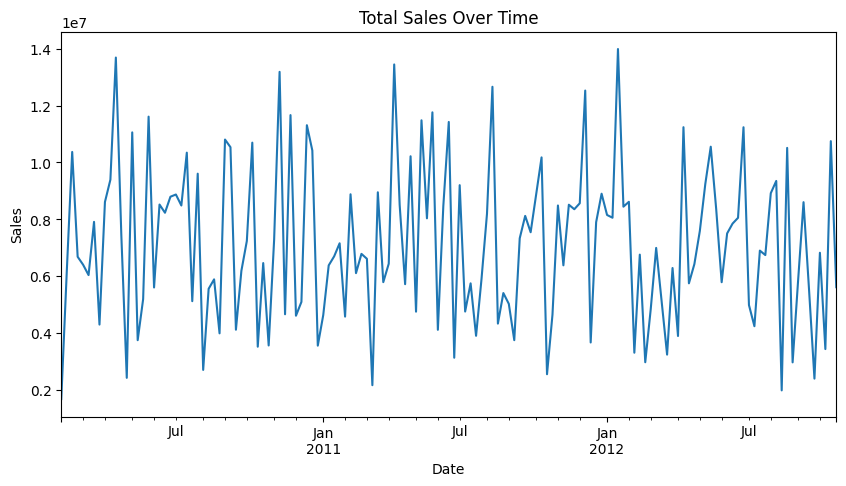

In [8]:
import matplotlib.pyplot as plt
df.groupby('date')['Weekly_Sales'].sum().plot(figsize=(10,5))
plt.title('Total Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()

In [10]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

print(df.columns)

Index(['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature',
       'Fuel_Price', 'CPI', 'Unemployment', 'date', 'month', 'year', 'Month',
       'Year'],
      dtype='object')


In [12]:
X = df[['Store','Holiday_Flag','Temperature','Fuel_Price','CPI','Unemployment','Month','Year']]
y = df['Weekly_Sales']

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# Features and target
X = df[['Store','Holiday_Flag','Temperature','Fuel_Price','CPI','Unemployment','Month','Year']]
y = df['Weekly_Sales']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model (FASTER)
rf = RandomForestRegressor(n_estimators=50, max_depth=5)
rf.fit(X_train, y_train)

# Predict
rf_pred = rf.predict(X_test)

# Accuracy
print("Random Forest R2 Score:", r2_score(y_test, rf_pred))

Random Forest R2 Score: 0.7015711890783412


In [15]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=50, max_depth=5)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

print("XGBoost R2 Score:", r2_score(y_test, xgb_pred))

XGBoost R2 Score: 0.8905094922402604


In [17]:
future = [[1, 0, 30, 3, 200, 7, 12, 2012]]  # Example month/year

predicted_sales = xgb.predict(future)[0]

current_stock = 5000000

print("Predicted Sales:", predicted_sales)

if predicted_sales > current_stock:
    print("Restock Required")
else:
    print("Stock is sufficient")

Predicted Sales: 1.8969099e+06
Stock is sufficient
